In [62]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('bmh')
plt.rcParams['axes.facecolor'] = 'white'

df = pd.read_csv('../data/df-prepared.csv')

In [63]:
df['Cargo type'].value_counts()

Cargo type
No additional information    456001
Category X                    43039
Reserved for future use       10042
Category Y                     7272
Category OS                    3693
Category Z                     2587
Name: count, dtype: int64

In [71]:
df['windSpeed'].max()

np.float64(18.92)

In [68]:
df.groupby('MMSI')['Length'].min().mean()

np.float64(142.22864768683274)

In [69]:
df.groupby('MMSI')['Width'].min().mean()

np.float64(21.31138790035587)

https://datalastic.com/blog/the-different-hazard-levels-through-ship-api/

- Category X - Pavojingas, sprogus krovinys (which applies to Large pressure vessels (e.g. 4000-tonne ethane vessels, 7000-tonne butane or propane vessels, 25 000 tonne ammonia vessels, 200-tonne chlorine vessels, and large power boilers))
- Category Y - Transporto priemonės ir šildytuvai (boilers)
- Category Z ir OS - Maža ir mažo slėgio įranga
- No additional information - nėra pavojau
- Reserved for future use - nepakrautas laivas

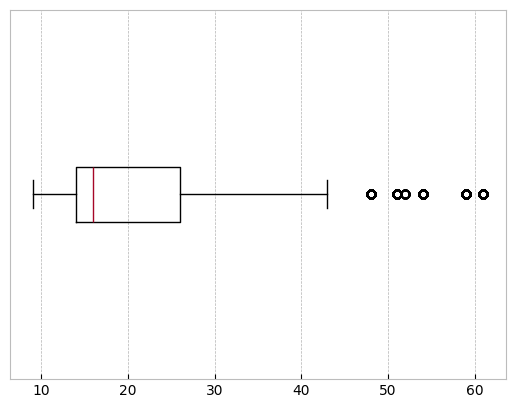

In [32]:
plt.boxplot(df['Width'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

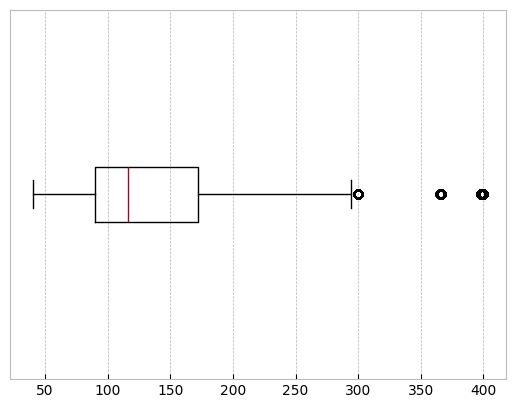

In [33]:
plt.boxplot(df['Length'], orientation='horizontal')
plt.yticks(ticks=[], labels=[])
plt.show()

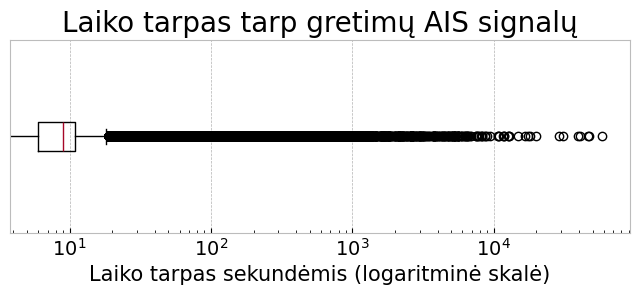

In [34]:
import numpy as np

gaps = np.load('../output/gaps.npy')
gaps = gaps[ ~np.isnan(gaps) ] * 60

fig, ax = plt.subplots(figsize=(8, 2.5))

ax.boxplot( gaps, orientation='horizontal' )
ax.set_xscale('log')

ax.set_xlabel('Laiko tarpas sekundėmis (logaritminė skalė)', fontdict={"size": 15})
ax.tick_params(axis='x', labelsize=14)
ax.set_yticks(ticks=[], labels=[])

ax.set_title('Laiko tarpas tarp gretimų AIS signalų', fontdict={"size": 20})

plt.savefig("laiko-tarpas.png", dpi=750)
plt.show()

In [35]:
df.columns

Index(['SOG', 'COG', 'Cargo type', 'Width', 'Length', 'currentSpeed', 'gust',
       'swellHeight', 'waveHeight', 'windSpeed', 'COG_vec_x', 'COG_vec_y',
       'currentDirection_vec_x', 'currentDirection_vec_y',
       'swellDirection_vec_x', 'swellDirection_vec_y', 'waveDirection_vec_x',
       'waveDirection_vec_y', 'windDirection_vec_x', 'windDirection_vec_y',
       'COG-dif', 'delta_dif', 'MMSI', 'day'],
      dtype='str')

In [36]:
col_list = list(df.columns)
col_list = [ col 
             for col in col_list
             if col not in [
                 'Cargo type',
                 'Width',
                 'Length',
                 'MMSI',
                 'day'
             ]
           ]

col_list

['SOG',
 'COG',
 'currentSpeed',
 'gust',
 'swellHeight',
 'waveHeight',
 'windSpeed',
 'COG_vec_x',
 'COG_vec_y',
 'currentDirection_vec_x',
 'currentDirection_vec_y',
 'swellDirection_vec_x',
 'swellDirection_vec_y',
 'waveDirection_vec_x',
 'waveDirection_vec_y',
 'windDirection_vec_x',
 'windDirection_vec_y',
 'COG-dif',
 'delta_dif']

In [37]:
col_list[16]

'windDirection_vec_y'

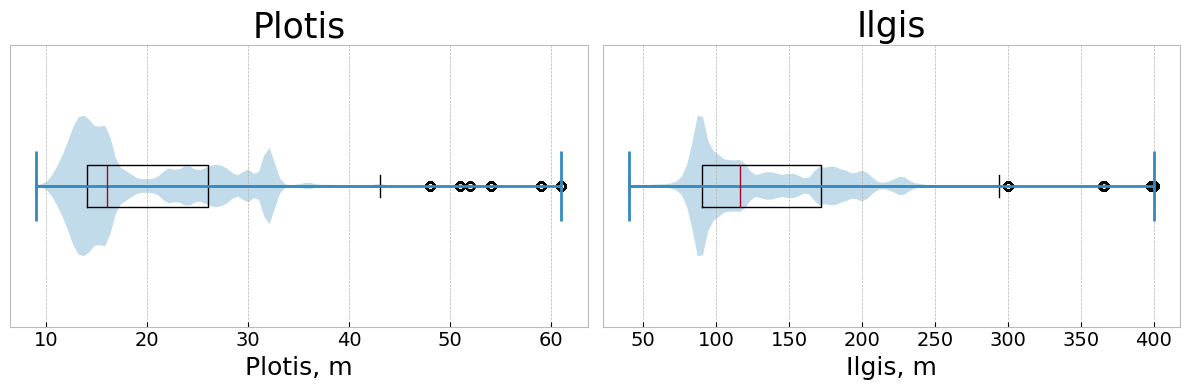

In [38]:
svarbus_kintamieji = {
    # 'SOG': ('Greitis', 'kn'),
    # 'COG': ('Kursas virš žemės', ''),
    # 'Cargo type': 'Krovinio tipas',
    'Width': ('Plotis', 'm'),
    'Length': ('Ilgis', 'm'),
}

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
plt.subplots_adjust(hspace=0.5)

for ix, ax in enumerate(axs.ravel()):
    if ix >= len(svarbus_kintamieji.items()):
        ax.axis('off')
        continue

    kint, (kint_lt, unit) = list( svarbus_kintamieji.items() )[ix]

    y = df[kint]

    # if kint not in ['SOG', 'COG']:
    #     y = np.cbrt(y)
    
    ax.boxplot( y, orientation='horizontal' )
    ax.violinplot( y, orientation='horizontal' )
    ax.tick_params(axis='x', labelsize=13)
    ax.set_yticks([])
    ax.set_title(kint_lt, size=25)
    ax.set_xlabel(f'{kint_lt}, {unit}', fontsize=18)
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('statiniai-kintamieji.png', dpi=750)
plt.show()

In [45]:
df[ df['SOG'] > 25 ][['MMSI', 'day', 'SOG']]

,MMSI,day,SOG
200770,246767000,2026-01-19,33.60
443072,412914000,2026-01-18,41.85


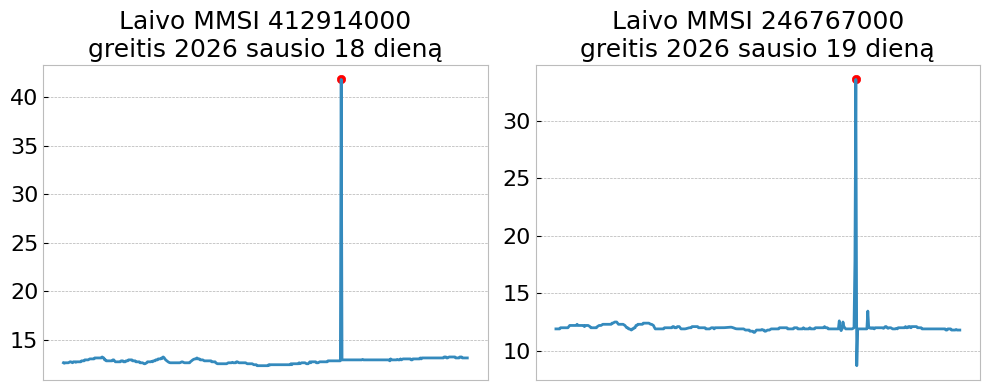

In [61]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 4))

df[ (df['MMSI'] == 412914000) & (df['day'] == '2026-01-18') ]['SOG'].plot(ax=ax1)
df[ (df['MMSI'] == 246767000) & (df['day'] == '2026-01-19') ]['SOG'].plot(ax=ax2)

ax1.set_title( 'Laivo MMSI 412914000\ngreitis 2026 sausio 18 dieną', fontsize=18)
ax1.set_xticks(ticks=[], labels=[])
ax1.tick_params(axis='y', labelsize=16)

ax2.set_title( 'Laivo MMSI 246767000\ngreitis 2026 sausio 19 dieną', fontsize=18)
ax2.set_xticks(ticks=[], labels=[])
ax2.tick_params(axis='y', labelsize=16)


ax1.scatter( df.index[df['SOG'] == 41.85], 41.85, color='red' )
ax2.scatter( df.index[df['SOG'] == 33.6], 33.6, color='red' )

plt.tight_layout()
plt.savefig('greicio-anomalijos.png', dpi=750)
plt.show()

<Axes: >

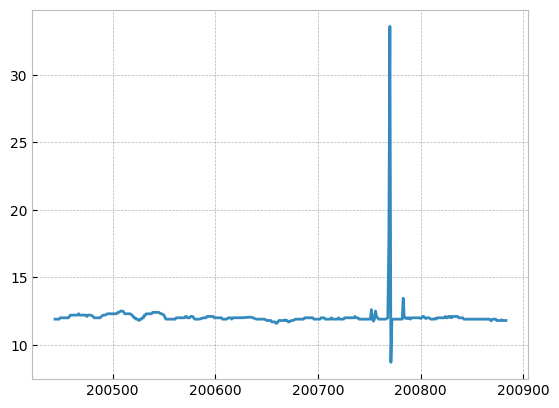

In [43]:
df[ (df['MMSI'] == 246767000) & (df['day'] == '2026-01-19') ]['SOG'].plot()

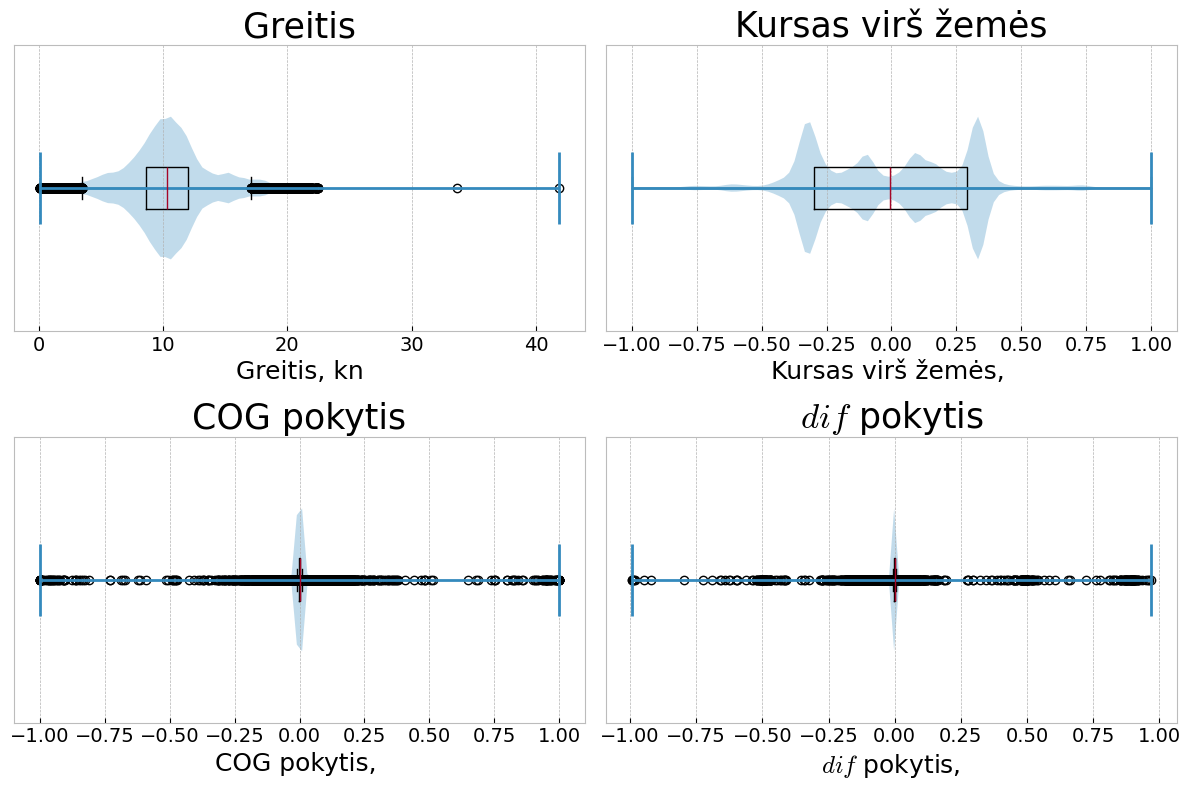

In [39]:
svarbus_kintamieji = {
    'SOG': ('Greitis', 'kn'),
    'COG': ('Kursas virš žemės', ''),
    # 'Cargo type': 'Krovinio tipas',
    # 'Width': 'Plotis',
    # 'Length': 'Ilgis',
    'COG-dif': ('COG pokytis', ''),
    'delta_dif': ('$dif$ pokytis', '')
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)

for ix, ax in enumerate(axs.ravel()):
    if ix >= len(svarbus_kintamieji.items()):
        ax.axis('off')
        continue

    kint, (kint_lt, unit) = list( svarbus_kintamieji.items() )[ix]

    y = df[kint]

    # if kint not in ['SOG', 'COG']:
    #     y = np.cbrt(y)
    
    ax.boxplot( y, orientation='horizontal' )
    ax.violinplot( y, orientation='horizontal' )
    ax.tick_params(axis='x', labelsize=13)
    ax.set_yticks([])
    ax.set_title(kint_lt, size=25)
    ax.set_xlabel(f'{kint_lt}, {unit}', fontsize=18)
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('trajektorijos-kintamieji.png', dpi=750)
plt.show()

In [12]:
df[df['SOG'] > 25][['Width', 'Length', 'Cargo type', 'MMSI']]

,Width,Length,Cargo type,MMSI
200770,19.0,142.0,No additional information,246767000
443072,32.0,225.0,No additional information,412914000


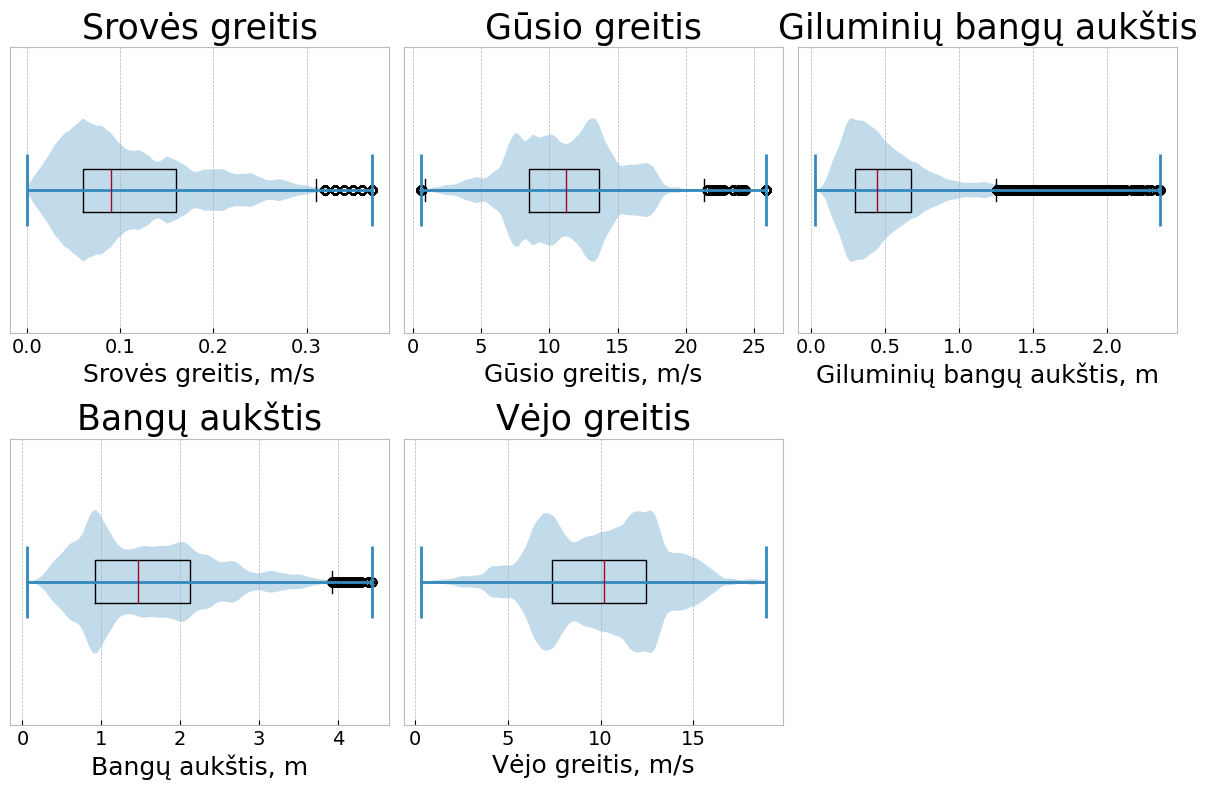

In [21]:
svarbus_kintamieji = {
    # 'SOG': ('Greitis', 'm/s'),
    # 'COG': 'Kursas virš žemės',
    # 'Cargo type': 'Krovinio tipas',
    # 'Width': 'Plotis',
    # 'Length': 'Ilgis',
    'currentSpeed': ('Srovės greitis', 'm/s'),
    'gust': ('Gūsio greitis', 'm/s'),
    'swellHeight': ('Giluminių bangų aukštis', 'm'),
    'waveHeight': ('Bangų aukštis', 'm'),
    'windSpeed': ('Vėjo greitis', 'm/s')
    # 'COG-dif': 'COG pokytis',
    # 'delta_dif': '$dif$ pokytis'
}

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))
plt.subplots_adjust(hspace=0.5)

for ix, ax in enumerate(axs.ravel()):
    if ix >= len(svarbus_kintamieji.items()):
        ax.axis('off')
        continue

    kint, (kint_lt, unit) = list( svarbus_kintamieji.items() )[ix]
    ax.boxplot( df[kint], orientation='horizontal' )
    ax.violinplot( df[kint], orientation='horizontal' )
    ax.tick_params(axis='x', labelsize=13)
    ax.set_yticks([])
    ax.set_title(kint_lt, size=25)
    ax.set_xlabel(f'{kint_lt}, {unit}', fontsize=18)
    ax.tick_params(axis='both', labelsize=14)

plt.tight_layout()
plt.savefig('meteorologiniai-kintamieji.png', dpi=750)
plt.show()

In [23]:
q1, q3 = np.quantile(gaps, q=[0.05, 0.95])
q1, q3

(np.float64(2.0), np.float64(20.0))

In [24]:
import seaborn as sns

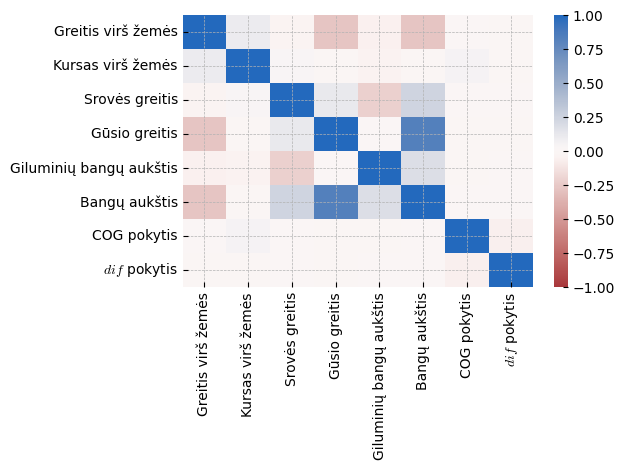

In [29]:
numeric_cols ={
    'SOG': 'Greitis virš žemės',
    'COG': 'Kursas virš žemės',
    # 'Width',
    # 'Length',
    'currentSpeed': 'Srovės greitis',
    'gust': 'Gūsio greitis',
    'swellHeight': 'Giluminių bangų aukštis',
    'waveHeight': 'Bangų aukštis',
    'COG-dif': 'COG pokytis',
    'delta_dif': '$dif$ pokytis'
}

sns.heatmap(
    df[ list(numeric_cols.keys()) ].corr(),
    cmap='vlag_r',
    vmin=-1
)


plt.xticks(
    ticks=np.arange(0.5, len(numeric_cols)+0.5, step=1),
    labels=numeric_cols.values(),
    rotation=90
)
plt.yticks(
    ticks=np.arange(0.5, len(numeric_cols)+0.5, step=1),
    labels=numeric_cols.values()
)

plt.tight_layout()
plt.savefig('corr-mat.png', dpi=750)
plt.show()

In [ ]:
numeric_cols ={
    'SOG': 'Greitis virš žemės',
    'COG': 'Kursas virš žemės',
    # 'Width',
    # 'Length',
    'currentSpeed': 'Srovės greitis',
    'gust': 'Gūsio greitis',
    'swellHeight': 'Giluminių bangų aukštis',
    'waveHeight': 'Bangų aukštis',
    'COG-dif': 'COG pokytis',
    'delta_dif': '$dif$ pokytis'
} 

sns.pairplot(
    df[ list(numeric_cols.keys()) ],
    # hue='Cargo type',
    # plot_kws={'alpha': 0.5}
)

plt.xticks(ticks=range(len(numeric_cols)), labels=numeric_cols.values(), rotation=90)
plt.yticks(ticks=range(len(numeric_cols)), labels=numeric_cols.values())

plt.tight_layout()
plt.savefig('sklaidos-matrica-bespalve.png', dpi=750)
plt.show()

KeyboardInterrupt: 